In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from autogluon.tabular import TabularDataset, TabularPredictor
import numpy as np
import pandas as pd

def train_logistic_regression(X_train, y_train):
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    return model

def train_decision_tree(X_train, y_train):
    # Prune model using 1SE rule via cost-complexity pruning
    base_model = DecisionTreeClassifier(random_state=42)
    path = base_model.cost_complexity_pruning_path(X_train, y_train)
    ccp_alphas = path.ccp_alphas[:-1]  # exclude trivial max alpha (root-only tree)

    # Subsample alphas to at most 50 for efficiency
    if len(ccp_alphas) > 50:
        indices = np.linspace(0, len(ccp_alphas) - 1, 50, dtype=int)
        ccp_alphas = ccp_alphas[indices]

    if len(ccp_alphas) == 0:
        model = DecisionTreeClassifier(random_state=42)
        model.fit(X_train, y_train)
        return model

    # Cross-validate each alpha candidate
    cv_scores, cv_stds = [], []
    for alpha in ccp_alphas:
        clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
        scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')
        cv_scores.append(scores.mean())
        cv_stds.append(scores.std())

    # 1SE rule: pick the largest alpha (most pruned) whose CV score >= best - 1 SE
    best_idx = np.argmax(cv_scores)
    threshold = cv_scores[best_idx] - cv_stds[best_idx] / np.sqrt(5)
    valid_idxs = [i for i, s in enumerate(cv_scores) if s >= threshold]
    selected_alpha = ccp_alphas[max(valid_idxs)]

    model = DecisionTreeClassifier(random_state=42, ccp_alpha=selected_alpha)
    model.fit(X_train, y_train)
    return model

def train_random_forest(X_train, y_train):
    param_dist = {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2'],
    }
    model = RandomForestClassifier(random_state=42, n_jobs=-1)
    search = RandomizedSearchCV(
        model, param_dist, n_iter=20, cv=5, scoring='f1_macro',
        random_state=42, n_jobs=-1
    )
    search.fit(X_train, y_train)
    return search.best_estimator_

def train_hist_gradient_boosting(X_train, y_train):
    param_dist = {
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [None, 3, 5, 7],
        'min_samples_leaf': [10, 20, 30, 50],
        'l2_regularization': [0.0, 0.1, 1.0],
    }
    model = HistGradientBoostingClassifier(random_state=42)
    search = RandomizedSearchCV(
        model, param_dist, n_iter=20, cv=5, scoring='f1_macro',
        random_state=42, n_jobs=-1
    )
    search.fit(X_train, y_train)
    return search.best_estimator_

def train_autogluon(X_train, y_train):
    train_data = TabularDataset(pd.concat([X_train, y_train], axis=1))
    predictor = TabularPredictor(label=y_train.name, eval_metric='f1_macro').fit(
        train_data, time_limit=30, presets='medium'
    )
    return predictor

/Users/dawsonren/miniconda3/envs/ml/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score
import pandas as pd
import numpy as np

def _get_proba(model, X):
    """Returns 1-D array of predicted probabilities for the positive class (anomaly=1)."""
    if isinstance(model, TabularPredictor):
        prob_df = model.predict_proba(TabularDataset(X))
        return prob_df[prob_df.columns[-1]].values
    else:
        return model.predict_proba(X)[:, 1]

def _get_pred(model, X):
    """Returns 1-D array of predicted class labels."""
    if isinstance(model, TabularPredictor):
        return model.predict(TabularDataset(X)).values
    else:
        return model.predict(X)

def _layer_metrics(layer_scores, y_true_layer):
    """Given per-layer scores and ground truth, return confusion matrix, AUCROC, macro F1."""
    y_pred = (layer_scores >= 0.5).astype(float)
    cm = confusion_matrix(y_true_layer, y_pred)
    aucroc = roc_auc_score(y_true_layer, layer_scores)
    f1 = f1_score(y_true_layer, y_pred, average='macro')
    return {'confusion_matrix': cm, 'aucroc': aucroc, 'f1_macro': f1}

def _format_metrics(cm, aucroc, f1):
    """Format a metrics block as a string. Assumes positive class = anomaly (1)."""
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (None, None, None, None)
    lines = [
        f"    Confusion Matrix:\n{cm}",
        f"    False Negatives (predicted in-control, actually anomaly): {fn}",
        f"    False Positives (predicted anomaly, actually in-control): {fp}",
        f"    AUCROC:   {aucroc:.4f}",
        f"    Macro F1: {f1:.4f}",
    ]
    return "\n".join(lines) + "\n"


LAYER_AGGS = {
    "mean":   lambda x: x.mean(),
    "median": lambda x: x.median(),
    "p75":    lambda x: x.quantile(0.75),
    "p90":    lambda x: x.quantile(0.90),
    "p95":    lambda x: x.quantile(0.95),
}


def evaluate_model(model, X_test, y_test):
    """
    Sample-level evaluation. Returns confusion matrix, AUCROC, and macro F1.
    Positive class is anomaly (1). Handles sklearn models and autogluon predictors.
    """
    y_prob = _get_proba(model, X_test)
    y_pred = _get_pred(model, X_test)

    cm = confusion_matrix(y_test, y_pred)
    aucroc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred, average='macro')

    return {'confusion_matrix': cm, 'aucroc': aucroc, 'f1_macro': f1}


def evaluate_model_layer_wise(model, X_test, y_test, layer_test):
    """
    Layer-level evaluation using multiple probability aggregations (mean, median,
    p75, p90, p95) across samples sharing the same layer. Ground truth per layer
    uses majority vote. Returns a dict keyed by aggregation name.
    """
    y_prob = _get_proba(model, X_test)

    df = pd.DataFrame({'layer': layer_test.values, 'y_prob': y_prob, 'y_true': y_test.values})

    y_true_layer = df.groupby('layer')['y_true'].agg(lambda x: x.mode().iloc[0])

    results = {}
    for agg_name, agg_fn in LAYER_AGGS.items():
        layer_scores = df.groupby('layer')['y_prob'].agg(agg_fn)
        # align index just in case
        layer_scores = layer_scores.loc[y_true_layer.index]
        results[agg_name] = _layer_metrics(layer_scores.values, y_true_layer.values)

    return results


def evaluate_control_chart_baseline(X_test, y_test, layer_test, threshold=1580):
    """
    Control chart baseline (layer-wise only). Flags a layer as anomaly (1) if its
    layerwise mean of the 'mean' feature exceeds the threshold. Ground truth uses
    majority vote. Positive class is anomaly (1).
    """
    df = pd.DataFrame({
        'layer': layer_test.values,
        'mean_signal': X_test['mean'].values,
        'y_true': y_test.values,
    })

    layer_df = df.groupby('layer').agg(
        layerwise_mean=('mean_signal', 'mean'),
        y_true=('y_true', lambda x: x.mode().iloc[0]),
    ).reset_index()

    # Higher layerwise mean → more likely anomaly (1)
    y_pred_layer = (layer_df['layerwise_mean'] > threshold).astype(float)
    y_true_layer = layer_df['y_true']
    prob_anomaly = (layer_df['layerwise_mean'] - layer_df['layerwise_mean'].min()) / \
                   (layer_df['layerwise_mean'].max() - layer_df['layerwise_mean'].min())

    cm = confusion_matrix(y_true_layer, y_pred_layer)
    aucroc = roc_auc_score(y_true_layer, prob_anomaly)
    f1 = f1_score(y_true_layer, y_pred_layer, average='macro')

    return {'confusion_matrix': cm, 'aucroc': aucroc, 'f1_macro': f1}

In [3]:
import os
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

ml_ready_dir = "./ml_ready_csvs/"
files = sorted([f for f in os.listdir(ml_ready_dir) if f.endswith(".csv")])

TARGET = "in_control"
SIMPLE_STATISTICS = ["mean", "max", "min", "stddev"]
SIMPLE_STATISTICS_AND_WAVELET = ["mean", "max", "min", "stddev", "wavelet_level_0_energy_ratio", "wavelet_level_1_energy_ratio", "wavelet_level_2_energy_ratio", "wavelet_level_3_energy_ratio", "wavelet_level_4_energy_ratio", "wavelet_level_5_energy_ratio"]
SIMPLE_STATISTICS_AND_WAVELET_ENTROPY = ["mean", "max", "min", "stddev", "wavelet_level_0_energy_ratio", "wavelet_level_1_energy_ratio", "wavelet_level_2_energy_ratio", "wavelet_level_3_energy_ratio", "wavelet_level_4_energy_ratio", "wavelet_level_5_energy_ratio", "wavelet_level_0_entropy", "wavelet_level_1_entropy", "wavelet_level_2_entropy", "wavelet_level_3_entropy", "wavelet_level_4_entropy", "wavelet_level_5_entropy"]

FEATURE_SETS = {
    "simple_statistics": SIMPLE_STATISTICS,
    "simple_statistics_and_wavelet": SIMPLE_STATISTICS_AND_WAVELET,
    "simple_statistics_wavelet_entropy": SIMPLE_STATISTICS_AND_WAVELET_ENTROPY,
}

MODELS = {
    "logistic_regression": train_logistic_regression,
    "decision_tree": train_decision_tree,
    "random_forest": train_random_forest,
    "hist_gradient_boosting": train_hist_gradient_boosting,
    "autogluon": train_autogluon,
}

# Compute global clean mask and train/test indices once.
# Use the most inclusive feature set so the same rows are kept across all feature sets.
df_ref = pd.read_csv(os.path.join(ml_ready_dir, files[0]))
global_clean_mask = df_ref[SIMPLE_STATISTICS_AND_WAVELET_ENTROPY + [TARGET, "file"]].notna().all(axis=1)

layer = (
    df_ref.loc[global_clean_mask, "file"]
    .str.extract(r"layer(\d+)\.csv$", expand=False)
    .astype(int)
    .reset_index(drop=True)
)

n_clean = global_clean_mask.sum()
# Flip target: 1 = anomaly (out-of-control), 0 = in-control
y_ref = 1 - df_ref.loc[global_clean_mask, TARGET].values
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(range(n_clean), y_ref, groups=layer))
print(f"Global split: {len(train_idx)} train rows, {len(test_idx)} test rows (from {n_clean} clean rows)")

layer_test = layer.iloc[test_idx].reset_index(drop=True)

# Pre-train SIMPLE_STATISTICS models once — these columns are identical across all wavelet files
print(f"\nPre-training SIMPLE_STATISTICS models (shared across all wavelet files)...")
df_clean_ss = df_ref[SIMPLE_STATISTICS + [TARGET]].loc[global_clean_mask].reset_index(drop=True)
X_ss = df_clean_ss[SIMPLE_STATISTICS]
y_ss = 1 - df_clean_ss[TARGET]
X_train_ss = X_ss.iloc[train_idx].reset_index(drop=True)
y_train_ss = y_ss.iloc[train_idx].reset_index(drop=True)

cached_ss_models = {}
for model_name, train_fn in MODELS.items():
    print(f"  Training {model_name}...", end=" ", flush=True)
    try:
        cached_ss_models[model_name] = train_fn(X_train_ss, y_train_ss)
        print("done")
    except Exception as e:
        cached_ss_models[model_name] = e
        print(f"ERROR: {e}")

for file in files:
    print(f"\n{'='*60}")
    print(f"Processing {file}...")
    df = pd.read_csv(os.path.join(ml_ready_dir, file))

    for feature_set_name, feature_set in FEATURE_SETS.items():
        print(f"\n  Feature set: {feature_set_name}")

        # Apply the global clean mask, then slice with the precomputed indices
        df_clean = df[feature_set + [TARGET]].loc[global_clean_mask].reset_index(drop=True)
        X = df_clean[feature_set]
        y = 1 - df_clean[TARGET]  # flip: 1 = anomaly, 0 = in-control

        X_train = X.iloc[train_idx].reset_index(drop=True)
        X_test  = X.iloc[test_idx].reset_index(drop=True)
        y_train = y.iloc[train_idx].reset_index(drop=True)
        y_test  = y.iloc[test_idx].reset_index(drop=True)

        # Control chart baseline (layer-wise only, no model needed)
        baseline_layer = evaluate_control_chart_baseline(X_test, y_test, layer_test)
        results = {
            "control_chart_baseline": {"sample": None, "layer": None, "layer_aggs": None, "baseline_layer": baseline_layer}
        }
        lm = baseline_layer
        print(f"    control_chart_baseline — Layer AUCROC={lm['aucroc']:.4f}  F1={lm['f1_macro']:.4f}")

        # For SIMPLE_STATISTICS, reuse cached models; otherwise train fresh
        if feature_set_name == "simple_statistics":
            models_to_eval = cached_ss_models
            print("    (reusing pre-trained SIMPLE_STATISTICS models)")
        else:
            models_to_eval = {}
            for model_name, train_fn in MODELS.items():
                print(f"    Training {model_name}...", end=" ", flush=True)
                try:
                    models_to_eval[model_name] = train_fn(X_train, y_train)
                    print("done")
                except Exception as e:
                    models_to_eval[model_name] = e
                    print(f"ERROR: {e}")

        for model_name, model in models_to_eval.items():
            if isinstance(model, Exception):
                results[model_name] = {"error": str(model)}
                continue
            try:
                sample_metrics = evaluate_model(model, X_test, y_test)
                layer_agg_metrics = evaluate_model_layer_wise(model, X_test, y_test, layer_test)
                results[model_name] = {'sample': sample_metrics, 'layer_aggs': layer_agg_metrics}
                # Print one line per aggregation
                for agg_name, lm in layer_agg_metrics.items():
                    print(
                        f"    {model_name} [{agg_name}] — "
                        f"Sample AUCROC={sample_metrics['aucroc']:.4f}  F1={sample_metrics['f1_macro']:.4f} | "
                        f"Layer AUCROC={lm['aucroc']:.4f}  F1={lm['f1_macro']:.4f}"
                    )
            except Exception as e:
                results[model_name] = {"error": str(e)}
                print(f"    {model_name} — ERROR: {e}")

        # Save results to a .txt file named by file and feature set
        file_base = file.replace(".csv", "")
        output_path = f"results_{file_base}_{feature_set_name}.txt"
        with open(output_path, "w") as out:
            out.write(f"File: {file}\n")
            out.write(f"Feature set: {feature_set_name}\n")
            out.write(f"Features: {feature_set}\n")
            out.write("=" * 60 + "\n\n")
            for model_name, metrics in results.items():
                out.write(f"Model: {model_name}\n")
                if "error" in metrics:
                    out.write(f"  ERROR: {metrics['error']}\n")
                elif model_name == "control_chart_baseline":
                    lm = metrics['baseline_layer']
                    out.write(f"  [Layer-level]\n")
                    out.write(_format_metrics(lm['confusion_matrix'], lm['aucroc'], lm['f1_macro']))
                else:
                    sm = metrics['sample']
                    out.write(f"  [Sample-level]\n")
                    out.write(_format_metrics(sm['confusion_matrix'], sm['aucroc'], sm['f1_macro']))
                    for agg_name, lm in metrics['layer_aggs'].items():
                        out.write(f"  [Layer-level ({agg_name})]\n")
                        out.write(_format_metrics(lm['confusion_matrix'], lm['aucroc'], lm['f1_macro']))
                out.write("\n")
        print(f"  -> Saved: {output_path}")

Global split: 22884 train rows, 5917 test rows (from 28801 clean rows)

Pre-training SIMPLE_STATISTICS models (shared across all wavelet files)...
  Training logistic_regression... done
  Training decision_tree... 

/Users/dawsonren/miniconda3/envs/ml/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dawsonren/miniconda3/envs/ml/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dawsonren/miniconda3/envs/ml/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


done
  Training random_forest... done
  Training hist_gradient_boosting... done
  Training autogluon... 

No path specified. Models will be saved in: "AutogluonModels/ag-20260311_034046"
Preset alias specified: 'medium' maps to 'medium_quality'.
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.5
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.6.0: Mon Jan 19 22:01:58 PST 2026; root:xnu-11417.140.69.708.3~1/RELEASE_ARM64_T6041
CPU Count:          12
Pytorch Version:    2.8.0
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       7.37 GB / 24.00 GB (30.7%)
Disk Space Avail:   199.74 GB / 460.43 GB (43.4%)
Presets specified: ['medium']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 30s
AutoGluon will save models to "/Users/dawsonren/Desktop/IEMS 490/IEMS_490_Proj/AutogluonModels/ag-20260311_034046"
Train D

done

Processing ml_ready_data_wavelet_method_db2.csv...

  Feature set: simple_statistics
    control_chart_baseline — Layer AUCROC=1.0000  F1=1.0000
    (reusing pre-trained SIMPLE_STATISTICS models)
    logistic_regression [mean] — Sample AUCROC=0.8848  F1=0.6745 | Layer AUCROC=0.9954  F1=0.7432
    logistic_regression [median] — Sample AUCROC=0.8848  F1=0.6745 | Layer AUCROC=1.0000  F1=0.7432
    logistic_regression [p75] — Sample AUCROC=0.8848  F1=0.6745 | Layer AUCROC=0.9909  F1=0.7432
    logistic_regression [p90] — Sample AUCROC=0.8848  F1=0.6745 | Layer AUCROC=0.9817  F1=0.7432
    logistic_regression [p95] — Sample AUCROC=0.8848  F1=0.6745 | Layer AUCROC=0.9772  F1=0.6898
    decision_tree [mean] — Sample AUCROC=0.6241  F1=0.6788 | Layer AUCROC=0.9589  F1=0.7432
    decision_tree [median] — Sample AUCROC=0.6241  F1=0.6788 | Layer AUCROC=0.6667  F1=0.7432
    decision_tree [p75] — Sample AUCROC=0.6241  F1=0.6788 | Layer AUCROC=0.6667  F1=0.7432
    decision_tree [p90] — Sample

...

    hist_gradient_boosting [mean] — Sample AUCROC=0.8803  F1=0.6802 | Layer AUCROC=0.9954  F1=0.7432
    hist_gradient_boosting [median] — Sample AUCROC=0.8803  F1=0.6802 | Layer AUCROC=1.0000  F1=0.7432
    hist_gradient_boosting [p75] — Sample AUCROC=0.8803  F1=0.6802 | Layer AUCROC=0.9954  F1=0.7432
    hist_gradient_boosting [p90] — Sample AUCROC=0.8803  F1=0.6802 | Layer AUCROC=0.9863  F1=0.6898
    hist_gradient_boosting [p95] — Sample AUCROC=0.8803  F1=0.6802 | Layer AUCROC=0.9817  F1=0.8265
    autogluon [mean] — Sample AUCROC=0.8592  F1=0.6674 | Layer AUCROC=0.9863  F1=0.7432
    autogluon [median] — Sample AUCROC=0.8592  F1=0.6674 | Layer AUCROC=1.0000  F1=0.7432
    autogluon [p75] — Sample AUCROC=0.8592  F1=0.6674 | Layer AUCROC=0.9954  F1=0.7432
    autogluon [p90] — Sample AUCROC=0.8592  F1=0.6674 | Layer AUCROC=0.9863  F1=0.8966
    autogluon [p95] — Sample AUCROC=0.8592  F1=0.6674 | Layer AUCROC=0.9772  F1=0.7361
  -> Saved: results_ml_ready_data_wavelet_method_sym3_sim

No path specified. Models will be saved in: "AutogluonModels/ag-20260311_035910"
Preset alias specified: 'medium' maps to 'medium_quality'.
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.5
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.6.0: Mon Jan 19 22:01:58 PST 2026; root:xnu-11417.140.69.708.3~1/RELEASE_ARM64_T6041
CPU Count:          12
Pytorch Version:    2.8.0
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       6.56 GB / 24.00 GB (27.4%)
Disk Space Avail:   197.69 GB / 460.43 GB (42.9%)
Presets specified: ['medium']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 30s
AutoGluon will save models to "/Users/dawsonren/Desktop/IEMS 490/IEMS_490_Proj/AutogluonModels/ag-20260311_035910"
Train D

done
    decision_tree [mean] — Sample AUCROC=0.8686  F1=0.6975 | Layer AUCROC=1.0000  F1=0.7432
    decision_tree [median] — Sample AUCROC=0.8686  F1=0.6975 | Layer AUCROC=0.9909  F1=0.7432
    decision_tree [p75] — Sample AUCROC=0.8686  F1=0.6975 | Layer AUCROC=0.9817  F1=0.7432
    decision_tree [p90] — Sample AUCROC=0.8686  F1=0.6975 | Layer AUCROC=0.9954  F1=0.8681
    decision_tree [p95] — Sample AUCROC=0.8686  F1=0.6975 | Layer AUCROC=0.9817  F1=0.7859
    random_forest [mean] — Sample AUCROC=0.8709  F1=0.7006 | Layer AUCROC=1.0000  F1=0.7432
    random_forest [median] — Sample AUCROC=0.8709  F1=0.7006 | Layer AUCROC=1.0000  F1=0.7432
    random_forest [p75] — Sample AUCROC=0.8709  F1=0.7006 | Layer AUCROC=1.0000  F1=0.7432
    random_forest [p90] — Sample AUCROC=0.8709  F1=0.7006 | Layer AUCROC=0.9863  F1=0.8265
    random_forest [p95] — Sample AUCROC=0.8709  F1=0.7006 | Layer AUCROC=0.9909  F1=0.8681
    hist_gradient_boosting [mean] — Sample AUCROC=0.8802  F1=0.7024 | Layer A

No path specified. Models will be saved in: "AutogluonModels/ag-20260311_040222"
Preset alias specified: 'medium' maps to 'medium_quality'.
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.5
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.6.0: Mon Jan 19 22:01:58 PST 2026; root:xnu-11417.140.69.708.3~1/RELEASE_ARM64_T6041
CPU Count:          12
Pytorch Version:    2.8.0
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       6.48 GB / 24.00 GB (27.0%)
Disk Space Avail:   197.41 GB / 460.43 GB (42.9%)
Presets specified: ['medium']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 30s
AutoGluon will save models to "/Users/dawsonren/Desktop/IEMS 490/IEMS_490_Proj/AutogluonModels/ag-20260311_040222"
Train D

done
    decision_tree [mean] — Sample AUCROC=0.8179  F1=0.6796 | Layer AUCROC=0.9817  F1=0.7432
    decision_tree [median] — Sample AUCROC=0.8179  F1=0.6796 | Layer AUCROC=0.9863  F1=0.7432
    decision_tree [p75] — Sample AUCROC=0.8179  F1=0.6796 | Layer AUCROC=0.9909  F1=0.7432
    decision_tree [p90] — Sample AUCROC=0.8179  F1=0.6796 | Layer AUCROC=0.9954  F1=0.7432
    decision_tree [p95] — Sample AUCROC=0.8179  F1=0.6796 | Layer AUCROC=0.9680  F1=0.6530
    random_forest [mean] — Sample AUCROC=0.8701  F1=0.7040 | Layer AUCROC=0.9954  F1=0.7432
    random_forest [median] — Sample AUCROC=0.8701  F1=0.7040 | Layer AUCROC=1.0000  F1=0.7432
    random_forest [p75] — Sample AUCROC=0.8701  F1=0.7040 | Layer AUCROC=0.9954  F1=0.7432
    random_forest [p90] — Sample AUCROC=0.8701  F1=0.7040 | Layer AUCROC=0.9954  F1=0.8966
    random_forest [p95] — Sample AUCROC=0.8701  F1=0.7040 | Layer AUCROC=0.9954  F1=0.8681
    hist_gradient_boosting [mean] — Sample AUCROC=0.8886  F1=0.7193 | Layer A

Retraining RandomForest on all clean data...
  Simple Statistics... done
  Simple Statistics + Wavelet... done
  Simple Statistics + Wavelet + Entropy... done


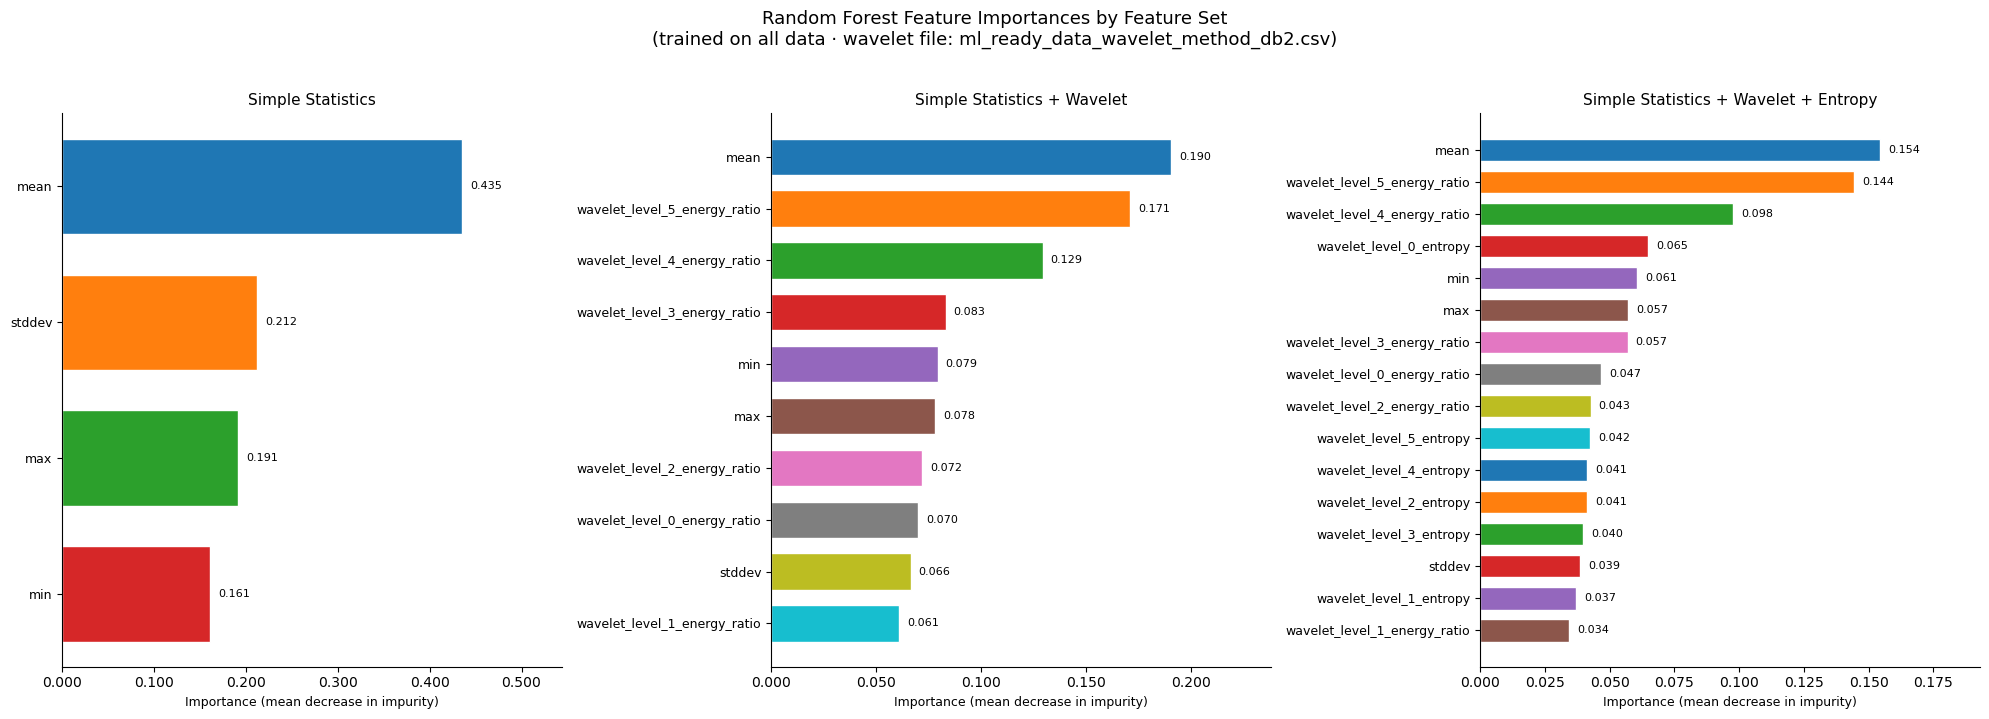

Saved: feature_importances_comparison.png


In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.ensemble import RandomForestClassifier

# ── Configuration ─────────────────────────────────────────────────────────────
# Chosen model: RandomForestClassifier, p90 aggregation
# (best layer-level p90 AUCROC across feature sets on db2)
# Representative wavelet file for wavelet feature sets
REPRESENTATIVE_WAVELET_FILE = "ml_ready_data_wavelet_method_db2.csv"

# ── Helpers ───────────────────────────────────────────────────────────────────
def retrain_rf_all_data(feature_set, wavelet_file):
    """Retrain RandomForestClassifier on ALL clean data for a given feature set."""
    df = pd.read_csv(os.path.join(ml_ready_dir, wavelet_file))
    df_clean = df[feature_set + [TARGET]].loc[global_clean_mask].reset_index(drop=True)
    X_all = df_clean[feature_set]
    y_all = 1 - df_clean[TARGET]  # flip: 1 = anomaly

    rf = RandomForestClassifier(
        n_estimators=300,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_all, y_all)
    return rf

# ── Retrain on all data for each feature set ──────────────────────────────────
print("Retraining RandomForest on all clean data...")
feature_set_configs = [
    ("Simple Statistics",                    SIMPLE_STATISTICS),
    ("Simple Statistics + Wavelet",          SIMPLE_STATISTICS_AND_WAVELET),
    ("Simple Statistics + Wavelet + Entropy", SIMPLE_STATISTICS_AND_WAVELET_ENTROPY),
]

trained = []
for label, feature_set in feature_set_configs:
    print(f"  {label}...", end=" ", flush=True)
    rf = retrain_rf_all_data(feature_set, REPRESENTATIVE_WAVELET_FILE)
    trained.append((label, feature_set, rf))
    print("done")

# ── Plot feature importances side by side ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(
    f"Random Forest Feature Importances by Feature Set\n"
    f"(trained on all data · wavelet file: {REPRESENTATIVE_WAVELET_FILE})",
    fontsize=13, y=1.02,
)

palette = plt.cm.tab10.colors

for ax, (label, feature_set, rf) in zip(axes, trained):
    importances = rf.feature_importances_
    order = importances.argsort()[::-1]          # descending
    sorted_features    = [feature_set[i] for i in order]
    sorted_importances = importances[order]

    bars = ax.barh(
        range(len(sorted_features)),
        sorted_importances,
        color=[palette[i % len(palette)] for i in range(len(sorted_features))],
        edgecolor="white",
        height=0.7,
    )
    ax.set_yticks(range(len(sorted_features)))
    ax.set_yticklabels(sorted_features, fontsize=9)
    ax.invert_yaxis()   # most important at top
    ax.set_xlabel("Importance (mean decrease in impurity)", fontsize=9)
    ax.set_title(label, fontsize=11)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.spines[["top", "right"]].set_visible(False)

    # Annotate each bar with its value
    x_max = sorted_importances[0]
    for bar, val in zip(bars, sorted_importances):
        ax.text(
            val + x_max * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", ha="left", fontsize=8,
        )
    ax.set_xlim(0, x_max * 1.25)

plt.tight_layout()
plt.savefig("feature_importances_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: feature_importances_comparison.png")